# Multi-class topic classifier v0 (minimal)

Minimal baseline: predict `topic` (10 classes) from `article_text`.

**In scope:** stratified split → fixed TF-IDF + multinomial Logistic Regression → test metrics (argmax) → OvR ROC overlay → coefficients → spot checks.

**Out of scope here:** GridSearch / CV, threshold analytics, Layer B abstain.

Fuller pipeline: [`ml_multi_v1.ipynb`](ml_multi_v1.ipynb).

Binary routing counterpart: [`ml_binary_v0.ipynb`](ml_binary_v0.ipynb).


## 1. Setup


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROC_ALPHA = 0.45


In [6]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    """Find data file whether the kernel cwd is project root or notebooks/."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )

DATA_PATH = resolve_data_path()
print("Loading:", DATA_PATH)


Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv


## 2. Load and label


In [8]:
df = pd.read_csv(DATA_PATH)
y = df["topic"]

print("shape:", df.shape)
print("nulls:", df[["article_text", "topic"]].isna().sum().to_dict())
print("\n# classes:", y.nunique())
print("\nlabel balance:")
print(y.value_counts())
print(y.value_counts(normalize=True).rename("fraction").round(3))
print("\nnote: smallest classes have n=10 → ~2 test rows after 80/20; metrics will be noisy.")


shape: (200, 12)
nulls: {'article_text': 0, 'topic': 0}

# classes: 10

label balance:
topic
cloud_computing             35
telecommunications          35
cybersecurity               25
consumer_electronics        20
enterprise_software         20
financial_services          20
healthcare                  15
retail_ecommerce            10
transportation_logistics    10
energy                      10
Name: count, dtype: int64
topic
cloud_computing             0.175
telecommunications          0.175
cybersecurity               0.125
consumer_electronics        0.100
enterprise_software         0.100
financial_services          0.100
healthcare                  0.075
retail_ecommerce            0.050
transportation_logistics    0.050
energy                      0.050
Name: fraction, dtype: float64

note: smallest classes have n=10 → ~2 test rows after 80/20; metrics will be noisy.


## 3. Stratified train / test split


In [10]:
X = df["article_text"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("\ntrain class counts:")
print(y_train.value_counts().sort_index())
print("\ntest class counts:")
print(y_test.value_counts().sort_index())


train: 160  test: 40

train class counts:
topic
cloud_computing             28
consumer_electronics        16
cybersecurity               20
energy                       8
enterprise_software         16
financial_services          16
healthcare                  12
retail_ecommerce             8
telecommunications          28
transportation_logistics     8
Name: count, dtype: int64

test class counts:
topic
cloud_computing             7
consumer_electronics        4
cybersecurity               5
energy                      2
enterprise_software         4
financial_services          4
healthcare                  3
retail_ecommerce            2
telecommunications          7
transportation_logistics    2
Name: count, dtype: int64


## 4. Fit fixed pipeline

No hyperparameter search — sensible defaults only.

Multinomial LR via `solver="lbfgs"` (sklearn default multi-class path; not `liblinear` OvR).


In [12]:
model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
CLASS_NAMES = list(model.named_steps["clf"].classes_)
print("fitted on", len(X_train), "train rows")
print("classes:", CLASS_NAMES)


fitted on 160 train rows
classes: ['cloud_computing', 'consumer_electronics', 'cybersecurity', 'energy', 'enterprise_software', 'financial_services', 'healthcare', 'retail_ecommerce', 'telecommunications', 'transportation_logistics']


## 5. Test performance (argmax)

Always predict a topic via `predict()` / argmax of class probabilities.

Primary metrics: **macro F1**, **macro OvR ROC-AUC**. No PR curves.


                          precision    recall  f1-score   support

         cloud_computing       0.50      0.29      0.36         7
    consumer_electronics       0.25      0.50      0.33         4
           cybersecurity       0.50      0.20      0.29         5
                  energy       0.00      0.00      0.00         2
     enterprise_software       0.75      0.75      0.75         4
      financial_services       0.25      0.25      0.25         4
              healthcare       0.00      0.00      0.00         3
        retail_ecommerce       0.25      0.50      0.33         2
      telecommunications       0.67      0.29      0.40         7
transportation_logistics       0.00      0.00      0.00         2

                accuracy                           0.30        40
               macro avg       0.32      0.28      0.27        40
            weighted avg       0.40      0.30      0.32        40

accuracy   : 0.3
F1 macro   : 0.2716
F1 weighted: 0.3194
ROC-AUC macro (O

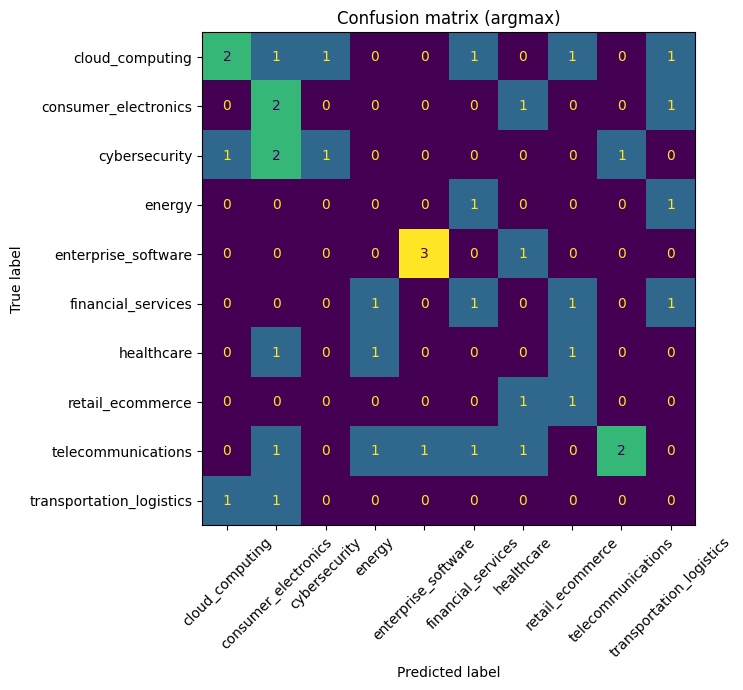

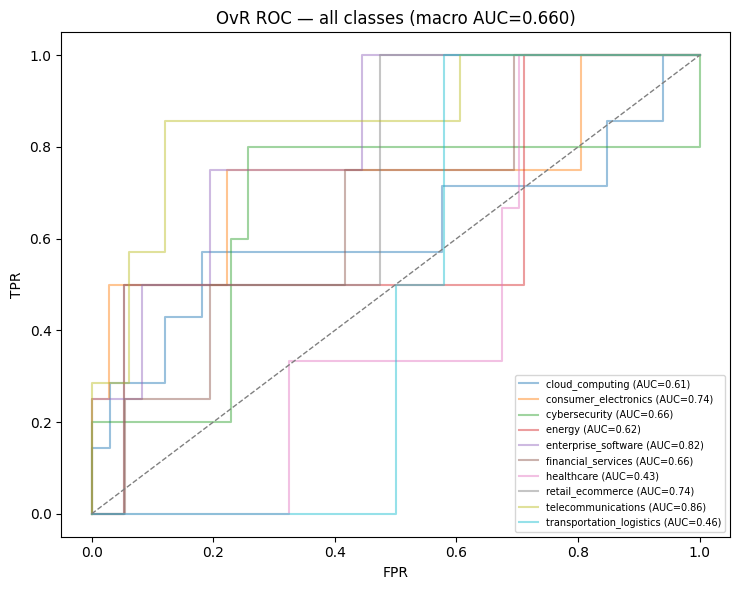

In [14]:
proba_test = model.predict_proba(X_test)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, labels=CLASS_NAMES, zero_division=0))
print("accuracy   :", round(accuracy_score(y_test, y_pred), 4))
print("F1 macro   :", round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4))
print("F1 weighted:", round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4))
print(
    "ROC-AUC macro (OvR):",
    round(roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro", labels=CLASS_NAMES), 4),
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=CLASS_NAMES),
    display_labels=CLASS_NAMES,
).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion matrix (argmax)")
plt.tight_layout()
plt.show()

# Overlay all OvR ROC curves
y_test_bin = label_binarize(y_test, classes=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_test[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], proba_test[:, i])
    ax.plot(fpr, tpr, alpha=ROC_ALPHA, label=f"{cls} (AUC={auc_i:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
macro_auc = roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro", labels=CLASS_NAMES)
ax.set_title(f"OvR ROC — all classes (macro AUC={macro_auc:.3f})")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


### Better than chance? — baseline comparison

Compare the fitted model to simple **label-only** baselines that **ignore `article_text`**:

| name | what it does |
|---|---|
| **TF-IDF + LR** | learns from article text |
| **Always majority class** | every row → most common **train** topic |
| **Random w/ train rates** | each row drawn from **train** topic frequencies |
| **Uniform random** | each row uniform over classes; ignores train mix |

If TF-IDF + LR beats these on the **same test set**, the model is using the text (not just label prevalence).


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
model,,,,,
TF-IDF + LR,0.300,0.3167,0.2771,0.2716,0.6597
Always majority class,0.175,0.0175,0.1000,0.0298,0.5000
Random w/ train rates,0.075,0.0625,0.0543,0.0578,0.4743
Uniform random,0.175,0.2033,0.1629,0.1622,0.5000



F1-macro lift vs best label-only baseline: +0.1094  (model=0.2716, best_baseline=0.1622)


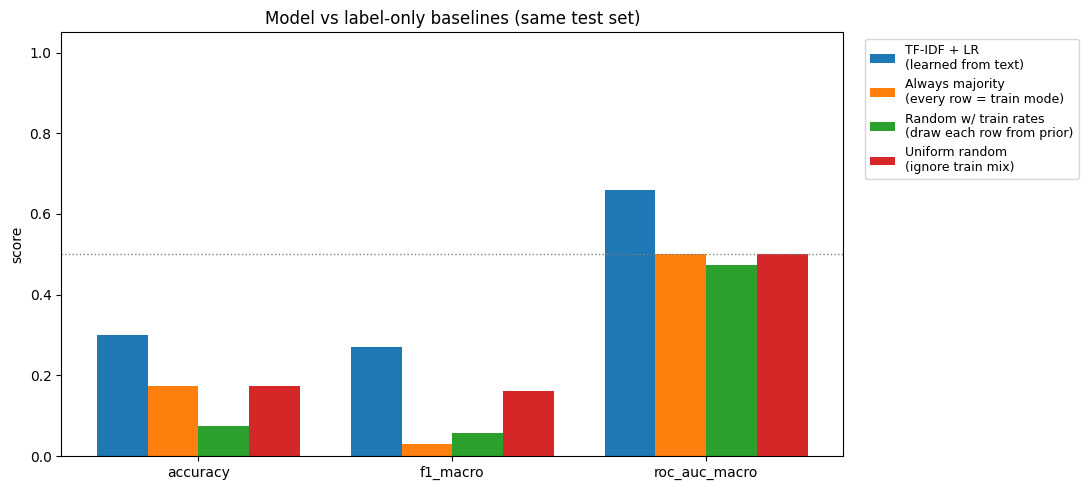

In [16]:
from sklearn.dummy import DummyClassifier


def eval_multi(name, y_true, y_hat, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "roc_auc_macro": roc_auc_score(
            y_true, y_score, multi_class="ovr", average="macro", labels=CLASS_NAMES
        ),
    }


MODEL_NAME = "TF-IDF + LR"
baseline_rows = [
    eval_multi(MODEL_NAME, y_test, y_pred, proba_test),
]

dummy_specs = [
    (
        "Always majority class",
        "most_frequent",
        "Always majority\n(every row = train mode)",
    ),
    (
        "Random w/ train rates",
        "stratified",
        "Random w/ train rates\n(draw each row from prior)",
    ),
    (
        "Uniform random",
        "uniform",
        "Uniform random\n(ignore train mix)",
    ),
]

legend_labels = {MODEL_NAME: "TF-IDF + LR\n(learned from text)"}
for name, strategy, legend in dummy_specs:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)  # X ignored; learns label prior only
    y_hat = dummy.predict(X_test)
    y_score = dummy.predict_proba(X_test)
    dummy_classes = list(dummy.classes_)
    aligned = np.zeros((len(y_hat), len(CLASS_NAMES)))
    for j, cls in enumerate(CLASS_NAMES):
        if cls in dummy_classes:
            aligned[:, j] = y_score[:, dummy_classes.index(cls)]
    baseline_rows.append(eval_multi(name, y_test, y_hat, aligned))
    legend_labels[name] = legend

baseline_cmp = pd.DataFrame(baseline_rows).set_index("model")
display(baseline_cmp.round(4))

best_dummy_f1 = baseline_cmp.drop(index=MODEL_NAME)["f1_macro"].max()
model_f1 = baseline_cmp.loc[MODEL_NAME, "f1_macro"]
print(
    f"\nF1-macro lift vs best label-only baseline: {model_f1 - best_dummy_f1:+.4f}  "
    f"(model={model_f1:.4f}, best_baseline={best_dummy_f1:.4f})"
)

plot_metrics = ["accuracy", "f1_macro", "roc_auc_macro"]
plot_df = baseline_cmp[plot_metrics]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_metrics))
width = 0.2
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=legend_labels[model_name])
ax.set_xticks(x + width * (len(plot_df) - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Model vs label-only baselines (same test set)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


## 6. Explainability — top coefficients per class

For multinomial LR, `coef_` has shape `(n_classes, n_features)`. Show top positive tokens for each topic.


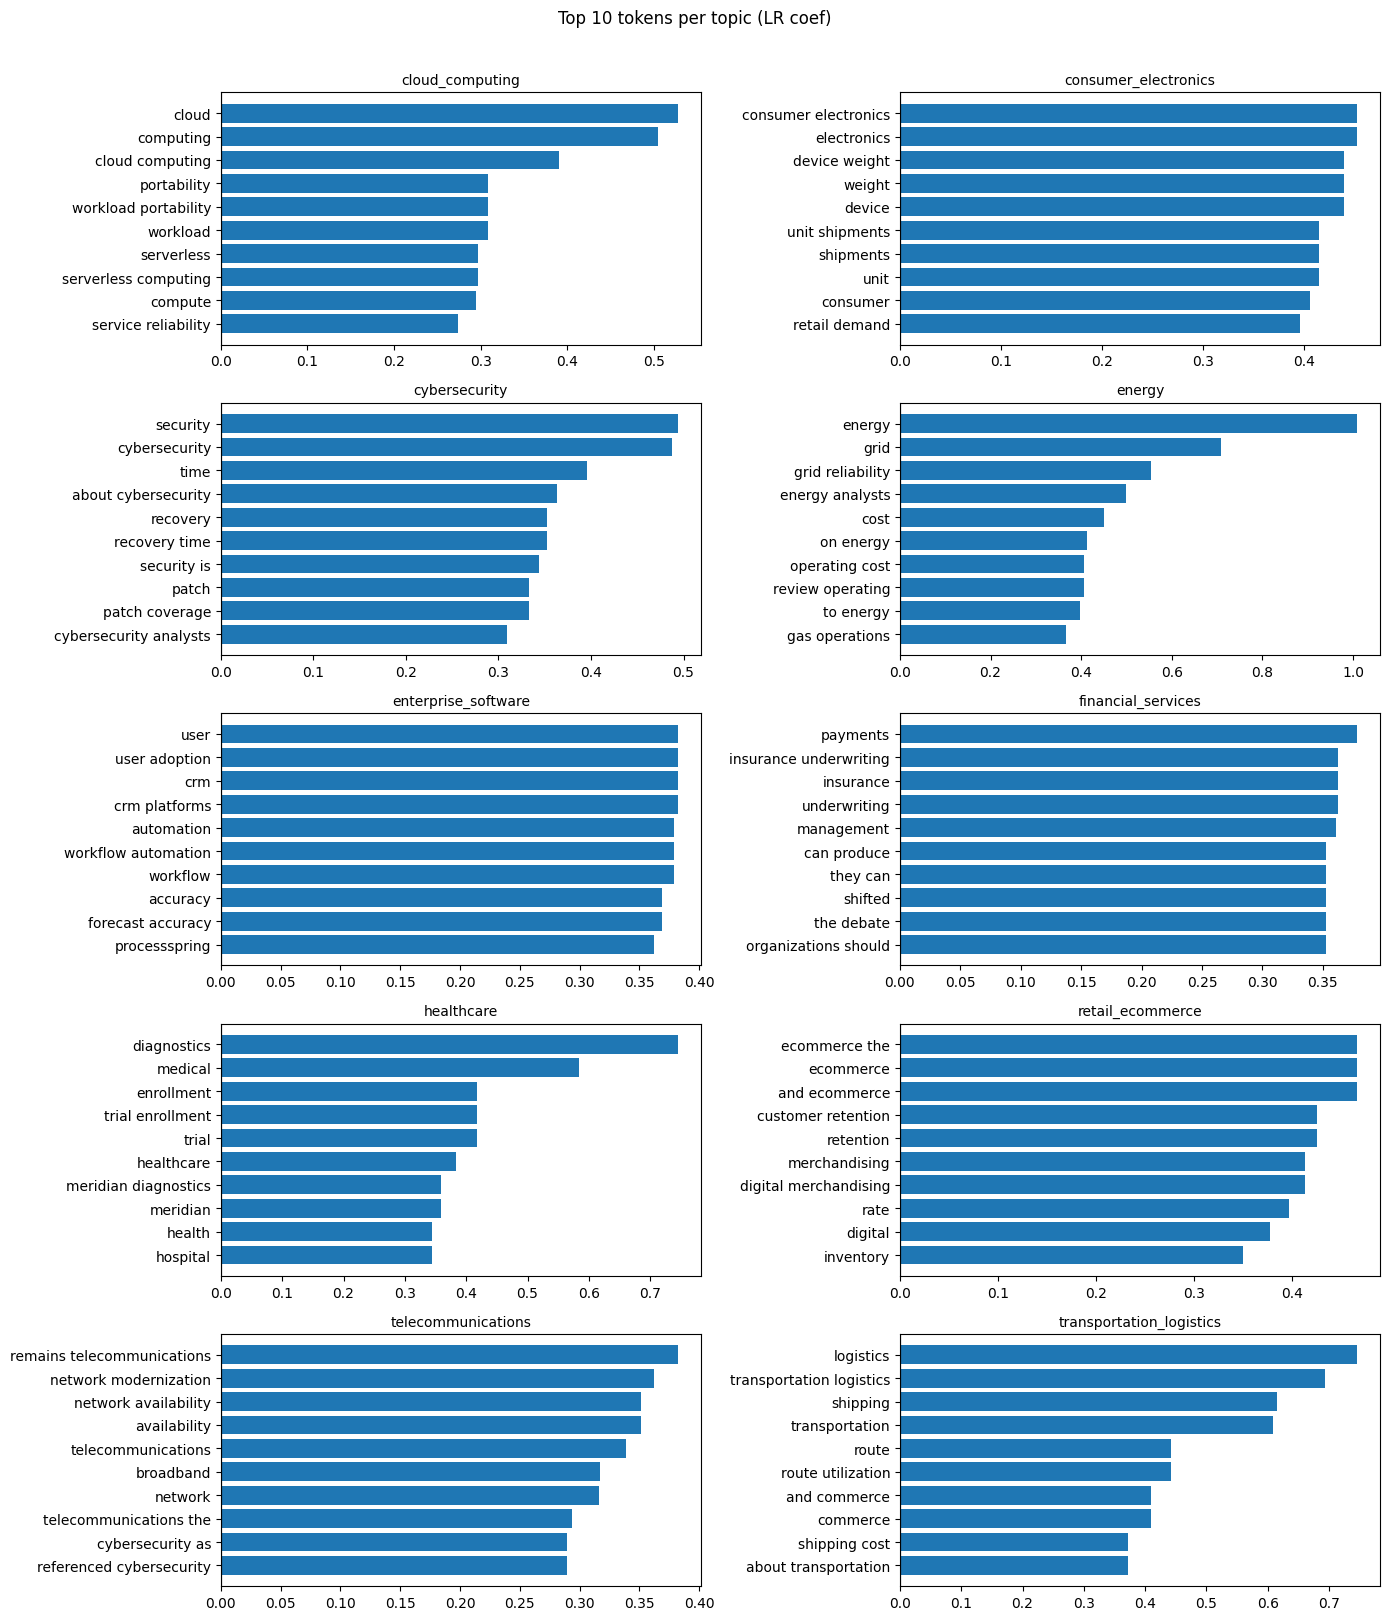

In [18]:
tfidf = model.named_steps["tfidf"]
clf = model.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_  # (n_classes, n_features)

TOP_N = 10
n_classes = len(CLASS_NAMES)
ncols = 2
nrows = int(np.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, cls, row in zip(axes, CLASS_NAMES, coefs):
    idx = np.argsort(row)[-TOP_N:]
    ax.barh(feature_names[idx], row[idx])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(cls, fontsize=10)

for ax in axes[n_classes:]:
    ax.axis("off")

fig.suptitle(f"Top {TOP_N} tokens per topic (LR coef)", y=1.01)
plt.tight_layout()
plt.show()


## 7. Spot checks — correct and incorrect predictions

Inspect a few high-confidence correct / incorrect test examples: true topic, predicted topic, `P(pred)`, `P(true)`, text snippet.


In [20]:
def show_spot_checks(n_per_bucket: int = 3, snippet_chars: int = 240):
    class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
    p_pred = proba_test[np.arange(len(y_pred)), [class_to_idx[c] for c in y_pred]]
    p_true = proba_test[np.arange(len(y_test)), [class_to_idx[c] for c in y_test.values]]

    test_df = pd.DataFrame({
        "article_id": df.loc[X_test.index, "article_id"].values,
        "title": df.loc[X_test.index, "title"].values,
        "article_text": X_test.values,
        "y_true": y_test.values,
        "y_pred": y_pred,
        "p_pred": p_pred,
        "p_true": p_true,
    })
    test_df["correct"] = test_df["y_true"] == test_df["y_pred"]

    buckets = {
        "correct (high P(pred))": test_df["correct"],
        "incorrect (high P(pred))": ~test_df["correct"],
    }

    for name, mask in buckets.items():
        subset = test_df.loc[mask].copy()
        print("=" * 72)
        print(f"{name}: {len(subset)} in test")
        if subset.empty:
            print("(none)")
            continue
        subset = subset.sort_values("p_pred", ascending=False)
        for _, row in subset.head(n_per_bucket).iterrows():
            snippet = row["article_text"][:snippet_chars].replace("\n", " ")
            print("-" * 72)
            print(
                f"article_id={row['article_id']} | true={row['y_true']} | "
                f"pred={row['y_pred']} | P(pred)={row['p_pred']:.3f} | P(true)={row['p_true']:.3f}"
            )
            print("title:", row["title"][:120])
            print("text:", snippet, "...")
        print()


show_spot_checks()


correct (high P(pred)): 12 in test
------------------------------------------------------------------------
article_id=V4-0140 | true=financial_services | pred=financial_services | P(pred)=0.260 | P(true)=0.260
title: The Market Debate Around Digital Banking Has Changed
text: The debate over digital banking has shifted from whether organizations should invest to how quickly they can produce measurable results.  The initiative includes phased deployment, new vendor contracts, staff training, and a revised measure ...
------------------------------------------------------------------------
article_id=V4-0134 | true=consumer_electronics | pred=consumer_electronics | P(pred)=0.204 | P(true)=0.204
title: Arcadia Electronics Announces Multi-Year Battery Design Investment
text: Arcadia Electronics announced that it is expanding its work in battery design after internal trials showed measurable gains in screen brightness.  The economics remain closely watched. Upfront investment can be signifi

## Save trained model

Saves the fitted TF-IDF + multinomial LR pipeline.

Artifact → `models/ml_multi_v0.joblib` (next to `data/`).


In [24]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_multi_v0.joblib"

joblib.dump(model, MODEL_PATH)
print("saved:", MODEL_PATH.resolve())
print("reload example: loaded = joblib.load(MODEL_PATH)")


saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v0.joblib
reload example: loaded = joblib.load(MODEL_PATH)


## Next

- Hyperparam tuning, CV diagnostics → [`ml_multi_v1.ipynb`](ml_multi_v1.ipynb)
- Binary routing path → [`ml_binary_v0.ipynb`](ml_binary_v0.ipynb) / [`ml_binary_v1.ipynb`](ml_binary_v1.ipynb)
